Ofcourse we are going to start with importing necessary libraries like we used to do. But this time (while working with NN and deep learning) Pytorch is going to be our best friend. It is a great library that Meta built, it allows enough customization but also user friendly with its built in functions as well.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import time
from tqdm import tqdm
import copy

The next important thing that we should do is changing the device to cuda. We should be using GPU to run things faster. Otherwise, it will take more time.

In [ ]:
#Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


For this example, we will work with CIFAR10 dataset. It is an vision dataset and has 10 different categories. Number of training samples are 50,000 and testing samples are 10,000. Each image is 32 x 32 pixels (so it is not huge).

In [ ]:

# PART 1: DATA PREPARATION
# ========================================

print("="*50)
print("LOADING CIFAR-10 DATASET")
print("="*50)

# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"\nDataset Info:")
print(f"- Training samples: {len(trainset)}")
print(f"- Test samples: {len(testset)}")
print(f"- Image shape: 32x32x3 (RGB)")
print(f"- Flattened input size: {32*32*3} = 3072 features")
print(f"- Number of classes: 10")

LOADING CIFAR-10 DATASET

Dataset Info:
- Training samples: 50000
- Test samples: 10000
- Image shape: 32x32x3 (RGB)
- Flattened input size: 3072 = 3072 features
- Number of classes: 10



Sample images from CIFAR-10:


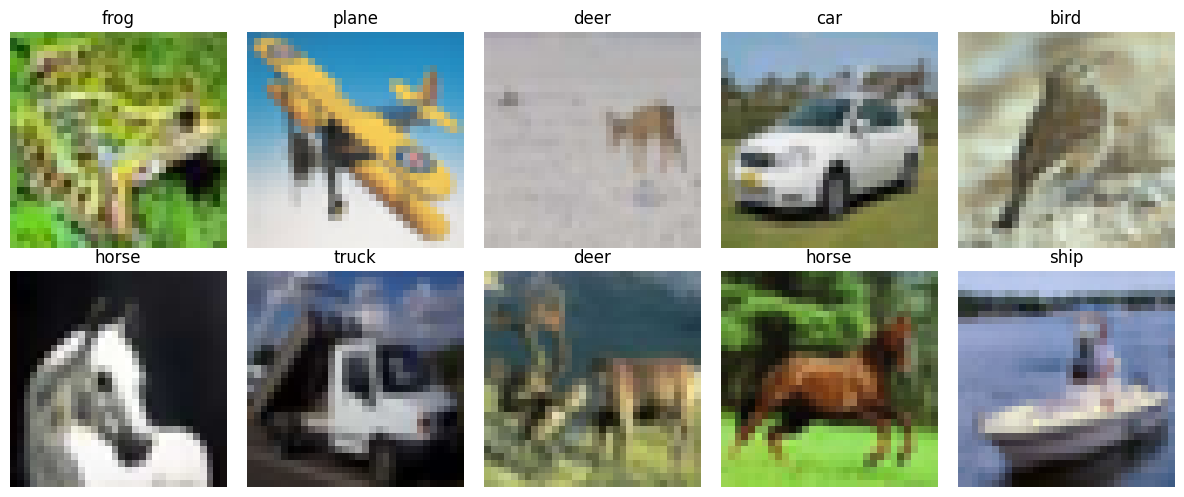

In [ ]:
# Visualize some training images
def show_images(dataloader, num_images=10):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        img = images[i].numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5  # Denormalize
        ax.imshow(img)
        ax.set_title(classes[labels[i]])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\nSample images from CIFAR-10:")
show_images(trainloader)

Then we will define our MLP architecture. The input size must match with the flattened image size. So since we have 32 x 32 pixel with rgb we will have 32 x 32 x 3 = 3072 (each color will bring another dimension so it will be 3).

Then we can define hidden layer numbers. In this case we defined 2 layers with input 512 and 256 nodes repsectively. But adjusting it is very easy.

You can go through the every hyperparameter in the model definition and play with them.

In [ ]:
class FlexibleMLP(nn.Module):
    """
    One flexible MLP that we can configure for ALL experiments
    """
    def __init__(self,
                 input_size=3072,
                 hidden_sizes=[512, 256],
                 num_classes=10,
                 activation='relu',
                 use_batchnorm=False,
                 dropout_rate=0.0,
                 init_method='kaiming'):
        super(FlexibleMLP, self).__init__()

        self.activation_name = activation
        self.use_batchnorm = use_batchnorm
        self.dropout_rate = dropout_rate

        # Build layers dynamically
        layers = []
        prev_size = input_size

        for i, hidden_size in enumerate(hidden_sizes):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))

            # Batch normalization (before activation)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            # Activation function
            layers.append(self._get_activation(activation))

            # Dropout
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

            prev_size = hidden_size

        # Output layer (no activation, CrossEntropyLoss applies softmax)
        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

        # Initialize weights
        self._initialize_weights(init_method)

    def _get_activation(self, name):
        """Return activation function by name"""
        activations = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'elu': nn.ELU(),
            'gelu': nn.GELU()
        }
        return activations.get(name.lower(), nn.ReLU())

    def _initialize_weights(self, method):
        """Initialize weights using specified method"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == 'zeros':
                    nn.init.zeros_(m.weight)
                elif method == 'ones':
                    nn.init.ones_(m.weight)
                elif method == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=0.01)
                elif method == 'xavier':
                    nn.init.xavier_uniform_(m.weight)
                elif method == 'kaiming':
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)

    def count_parameters(self):
        """Count trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


In [ ]:
# TRAINING FUNCTION WITH DETAILED METRICS

def train_and_evaluate(model,
                       trainloader,
                       testloader,
                       epochs=10,
                       lr=0.001,
                       optimizer_name='adam',
                       weight_decay=0,
                       scheduler_type=None,
                       track_gradients=False,
                       verbose=True):

    criterion = nn.CrossEntropyLoss()

    # Create optimizer
    if optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd_momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Create scheduler if requested
    scheduler = None
    if scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    elif scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Tracking variables
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'learning_rates': [],
        'gradient_norms': [] if track_gradients else None,
        'gradient_per_layer': [] if track_gradients else None
    }

    for epoch in range(epochs):
        # ============ TRAINING ============
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        epoch_gradients = []

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}', disable=not verbose)
        for batch_idx, (inputs, labels) in enumerate(pbar):
            # Flatten images
            inputs = inputs.view(inputs.size(0), -1)
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Track gradients
            if track_gradients and batch_idx == 0:  # Track first batch only
                total_norm = 0
                layer_grads = []
                for p in model.parameters():
                    if p.grad is not None:
                        param_norm = p.grad.data.norm(2)
                        total_norm += param_norm.item() ** 2
                        layer_grads.append(p.grad.abs().mean().item())
                total_norm = total_norm ** 0.5
                epoch_gradients.append(total_norm)
                if epoch == 0:  # Save layer-wise gradients for first epoch
                    if history['gradient_per_layer'] is not None:
                        history['gradient_per_layer'] = layer_grads

            optimizer.step()

            # Track metrics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            if verbose:
                pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100.*train_correct/train_total:.2f}%'
                })

        # Calculate epoch training metrics
        avg_train_loss = train_loss / len(trainloader)
        train_accuracy = 100. * train_correct / train_total

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)

        if track_gradients and len(epoch_gradients) > 0:
            history['gradient_norms'].append(np.mean(epoch_gradients))

        # ============ EVALUATION ============
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.view(inputs.size(0), -1)
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        avg_test_loss = test_loss / len(testloader)
        test_accuracy = 100. * test_correct / test_total

        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_accuracy)

        # Track learning rate
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rates'].append(current_lr)

        # Update scheduler
        if scheduler is not None:
            scheduler.step()

        if verbose:
            print(f'Epoch {epoch+1}/{epochs} | '
                  f'Train Loss: {avg_train_loss:.4f} | '
                  f'Train Acc: {train_accuracy:.2f}% | '
                  f'Test Loss: {avg_test_loss:.4f} | '
                  f'Test Acc: {test_accuracy:.2f}%')

    return history

**Experiment 1: Activation Function and a Silent Killer**

In the Experiment below, we will try different activation functions from sigmoid to Leaky Relu. We will observe the training vs test accuracies and select the winning activation.

In [ ]:
# EXPERIMENT 1: ACTIVATION FUNCTIONS

print("\nWe'll test the SAME network architecture with different activations")
print("and PROVE why ReLU works better by tracking gradients!\n")

# Baseline configuration
BASE_CONFIG = {
    'input_size': 3072,
    'hidden_sizes': [256, 128],
    'num_classes': 10,
    'use_batchnorm': False,
    'dropout_rate': 0.0,
    'init_method': 'kaiming'
}

activations_to_test = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
activation_results = {}

for activation in activations_to_test:
    print(f"\n{'='*70}")
    print(f"Testing: {activation.upper()} activation")
    print(f"{'='*70}")

    # Create model with only activation changed
    model = FlexibleMLP(
        **BASE_CONFIG,
        activation=activation
    ).to(device)

    print(f"Parameters: {model.count_parameters():,}")

    # Train with gradient tracking
    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=8,
        lr=0.001,
        optimizer_name='adam',
        track_gradients=True,
        verbose=True
    )

    activation_results[activation] = history



We'll test the SAME network architecture with different activations
and PROVE why ReLU works better by tracking gradients!


Testing: SIGMOID activation
Parameters: 820,874


Epoch 1/8: 100%|██████████| 391/391 [00:16<00:00, 23.38it/s, loss=1.7723, acc=38.30%]


Epoch 1/8 | Train Loss: 1.7584 | Train Acc: 38.30% | Test Loss: 1.6291 | Test Acc: 43.66%


Epoch 2/8: 100%|██████████| 391/391 [00:12<00:00, 30.50it/s, loss=1.6326, acc=44.89%]


Epoch 2/8 | Train Loss: 1.5812 | Train Acc: 44.89% | Test Loss: 1.5565 | Test Acc: 46.13%


...

Epoch 6/8 | Train Loss: 1.1240 | Train Acc: 60.41% | Test Loss: 1.4246 | Test Acc: 51.47%


Epoch 7/8: 100%|██████████| 391/391 [00:12<00:00, 30.26it/s, loss=1.2014, acc=62.96%]


Epoch 7/8 | Train Loss: 1.0616 | Train Acc: 62.96% | Test Loss: 1.4531 | Test Acc: 51.46%


Epoch 8/8: 100%|██████████| 391/391 [00:12<00:00, 30.14it/s, loss=1.0170, acc=64.75%]


Epoch 8/8 | Train Loss: 1.0041 | Train Acc: 64.75% | Test Loss: 1.4645 | Test Acc: 51.60%


We have run different activations and now we want to clearly see what is going on with gradients when we change the activations.


Gradient Norms Throughout Training:
----------------------------------------------------------------------
Activation      Epoch 1      Epoch 4      Epoch 8     
----------------------------------------------------------------------
sigmoid         2.220008     0.455713     0.695523    
tanh            4.014010     1.143375     1.212053    
relu            3.574626     1.775860     2.117584    
leaky_relu      3.505860     1.974570     2.163883    
Sigmoid/Tanh have SMALLER gradients → slower weight updates!
ReLU/Leaky ReLU have LARGER gradients → faster learning!


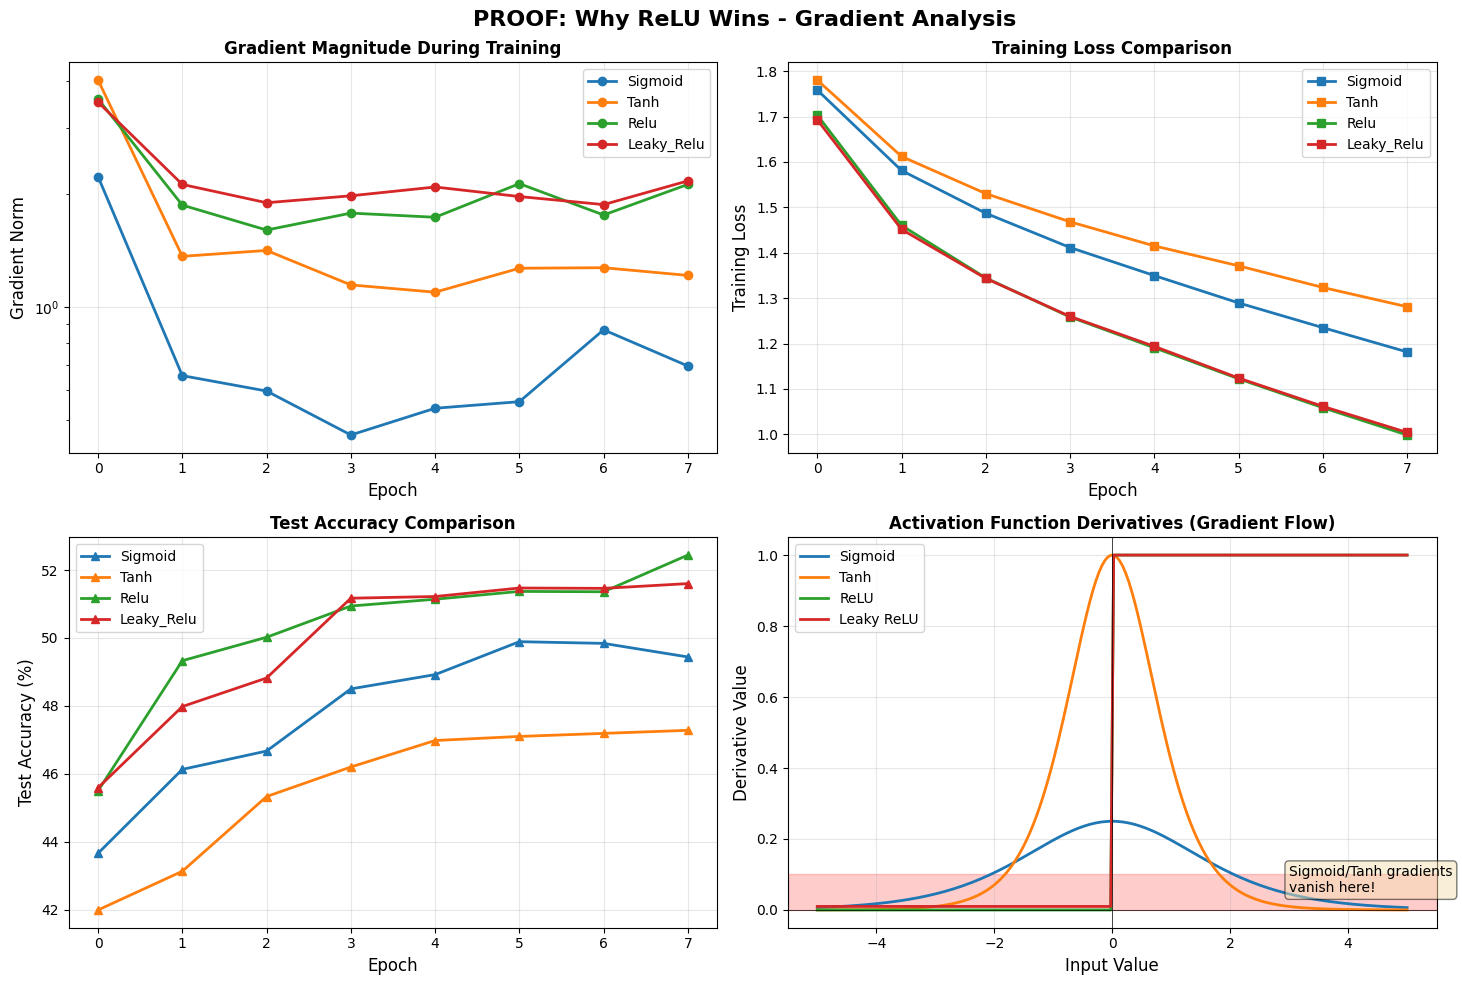

In [ ]:
# PROOF 1: WHY SIGMOID/TANH FAIL - GRADIENT ANALYSIS

# Show gradient magnitudes
print("\nGradient Norms Throughout Training:")
print("-" * 70)
print(f"{'Activation':<15} {'Epoch 1':<12} {'Epoch 4':<12} {'Epoch 8':<12}")
print("-" * 70)

for activation in activations_to_test:
    grads = activation_results[activation]['gradient_norms']
    print(f"{activation:<15} {grads[0]:<12.6f} {grads[3]:<12.6f} {grads[7]:<12.6f}")


print("Sigmoid/Tanh have SMALLER gradients → slower weight updates!")
print("ReLU/Leaky ReLU have LARGER gradients → faster learning!")

# Visualize gradient flow
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('PROOF: Why ReLU Wins - Gradient Analysis', fontsize=16, fontweight='bold')

# Plot 1: Gradient norms over training
ax = axes[0, 0]
for activation in activations_to_test:
    grads = activation_results[activation]['gradient_norms']
    ax.plot(grads, marker='o', label=activation.title(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Gradient Norm', fontsize=12)
ax.set_title('Gradient Magnitude During Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 2: Training loss
ax = axes[0, 1]
for activation in activations_to_test:
    loss = activation_results[activation]['train_loss']
    ax.plot(loss, marker='s', label=activation.title(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Test accuracy
ax = axes[1, 0]
for activation in activations_to_test:
    acc = activation_results[activation]['test_acc']
    ax.plot(acc, marker='^', label=activation.title(), linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Activation function derivatives
ax = axes[1, 1]
x = np.linspace(-5, 5, 200)

# Sigmoid derivative
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_grad = sigmoid * (1 - sigmoid)
ax.plot(x, sigmoid_grad, label='Sigmoid', linewidth=2)

# Tanh derivative
tanh = np.tanh(x)
tanh_grad = 1 - tanh**2
ax.plot(x, tanh_grad, label='Tanh', linewidth=2)

# ReLU derivative
relu_grad = (x > 0).astype(float)
ax.plot(x, relu_grad, label='ReLU', linewidth=2)

# Leaky ReLU derivative
leaky_grad = np.where(x > 0, 1, 0.01)
ax.plot(x, leaky_grad, label='Leaky ReLU', linewidth=2)

ax.set_xlabel('Input Value', fontsize=12)
ax.set_ylabel('Derivative Value', fontsize=12)
ax.set_title('Activation Function Derivatives (Gradient Flow)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# Highlight vanishing gradient region
ax.axhspan(0, 0.1, alpha=0.2, color='red', label='Vanishing Gradient Zone')
ax.text(3, 0.05, 'Sigmoid/Tanh gradients\nvanish here!', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('proof_activation_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

**Exercise 1.2 : Lets increase the depth and see what happens again**

This have observed that ReLu is having higher gradients than the other activation functions. This time, we will increase the depth of the network and again evaluate each of them and ofcourse we will observe the changing gradients.


Let's make the network DEEPER (8 layers) and see what happens...
We'll train 3 deep networks: Sigmoid, Tanh, and ReLU
Hypothesis: Sigmoid/Tanh will fail or return worse results

Training DEEP network with SIGMOID activation
Parameters: 1,184,010
Architecture: 8 layers (1 input + 6 hidden + 1 output)

Analyzing gradients BEFORE training...


Epoch 1/10: 100%|██████████| 391/391 [00:13<00:00, 29.47it/s, loss=1.9599, acc=18.18%]


Epoch 1/10 | Train Loss: 2.1030 | Train Acc: 18.18% | Test Loss: 1.9959 | Test Acc: 22.99%


Epoch 2/10: 100%|██████████| 391/391 [00:13<00:00, 29.60it/s, loss=1.9299, acc=25.89%]


Epoch 2/10 | Train Loss: 1.9051 | Train Acc: 25.89% | Test Loss: 1.8390 | Test Acc: 30.33%


...

Epoch 9/10: 100%|██████████| 391/391 [00:13<00:00, 28.97it/s, loss=1.0443, acc=64.25%]


Epoch 9/10 | Train Loss: 1.0062 | Train Acc: 64.25% | Test Loss: 1.4340 | Test Acc: 51.79%


Epoch 10/10: 100%|██████████| 391/391 [00:13<00:00, 29.11it/s, loss=1.1675, acc=66.46%]


Epoch 10/10 | Train Loss: 0.9481 | Train Acc: 66.46% | Test Loss: 1.4304 | Test Acc: 52.74%

Analyzing gradients AFTER epoch 10


/tmp/ipykernel_853/3592285382.py:239: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.savefig('proof_deep_vanishing_gradient_complete.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_853/3592285382.py:239: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.savefig('proof_deep_vanishing_gradient_complete.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


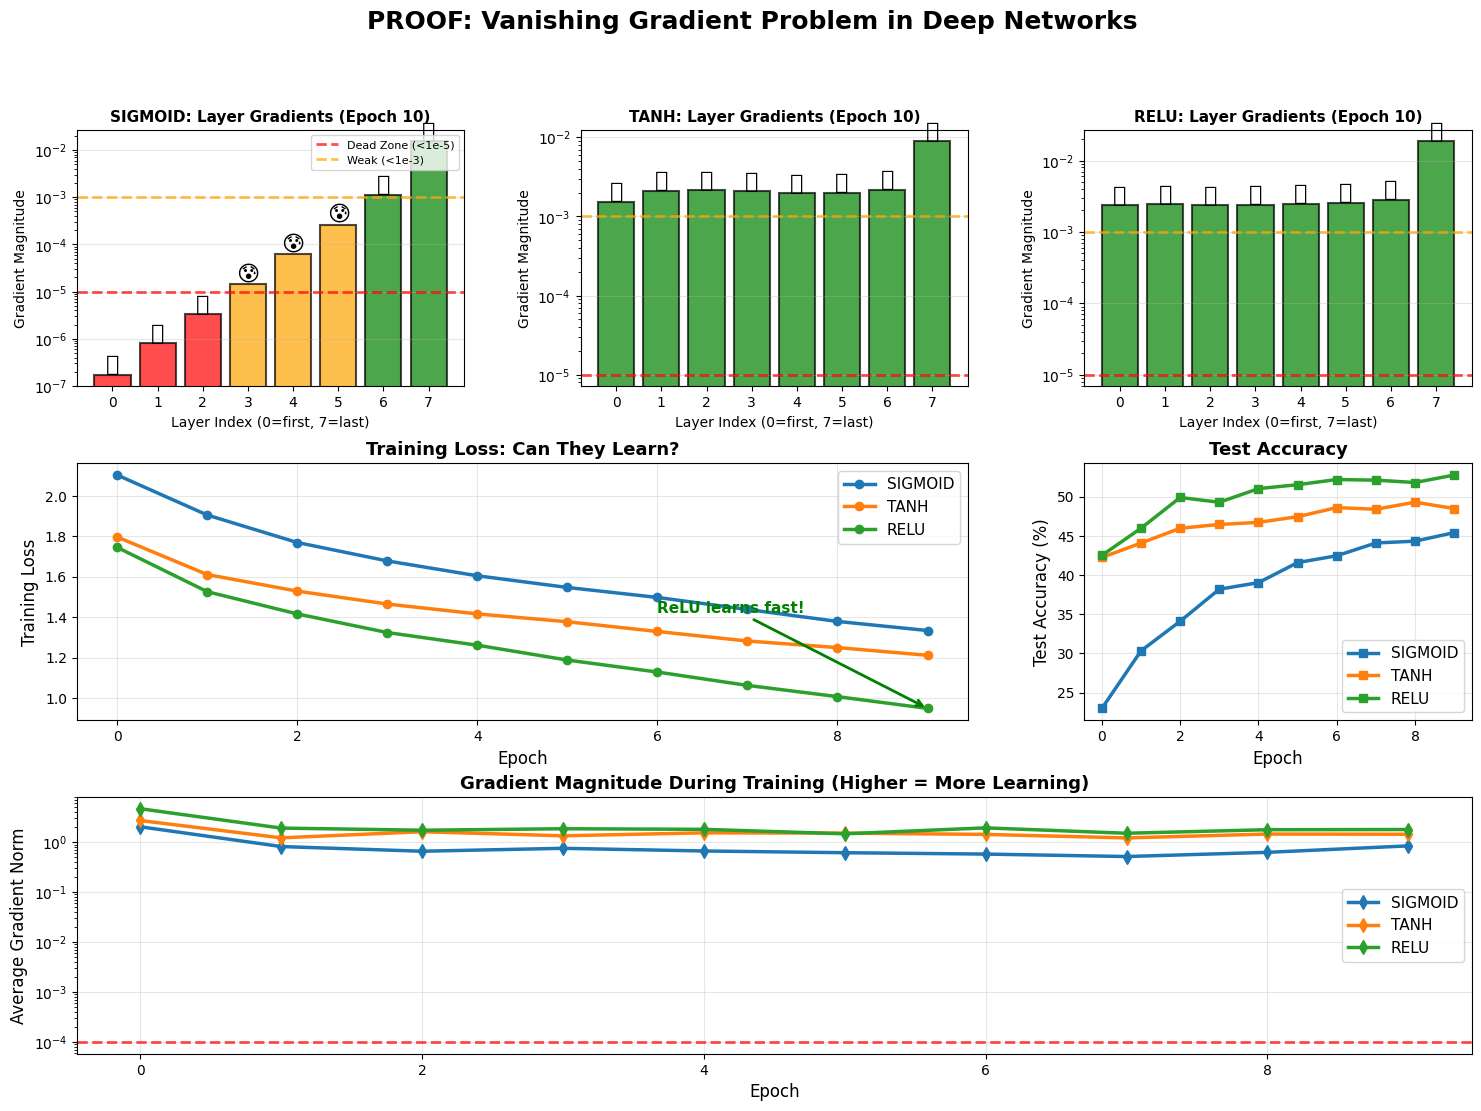


SIGMOID Network (8 layers):
----------------------------------------------------------------------
Layer    Initial Gradient     Status              
----------------------------------------------------------------------
Layer 0  1.73e-07             💀 DEAD (can't learn)
Layer 1  7.97e-07             💀 DEAD (can't learn)
Layer 2  3.31e-06             💀 DEAD (can't learn)
Layer 3  1.44e-05             😰 VERY WEAK
Layer 4  6.14e-05             😰 VERY WEAK
Layer 5  2.61e-04             😰 VERY WEAK
Layer 6  1.12e-03             😐 WEAK
Layer 7  1.53e-02             💪 STRONG
----------------------------------------------------------------------
Summary: 3 dead, 3 weak, 2 healthy

TANH Network (8 layers):
----------------------------------------------------------------------
Layer    Initial Gradient     Status              
----------------------------------------------------------------------
Layer 0  1.52e-03             😐 WEAK
Layer 1  2.11e-03             😐 WEAK
Layer 2  2.14e-03       

In [ ]:
# PROOF 2: DEEP NETWORK - VANISHING GRADIENT

print("\nLet's make the network DEEPER (8 layers) and see what happens...")
print("We'll train 3 deep networks: Sigmoid, Tanh, and ReLU")
print("Hypothesis: Sigmoid/Tanh will fail or return worse results")

class DeepMLP(nn.Module):
    """Deep network where we can track each layer's gradients"""
    def __init__(self, activation='sigmoid', depth=8, hidden_size=256):
        super(DeepMLP, self).__init__()

        self.layers = nn.ModuleList()
        self.activation_name = activation

        # Input layer
        self.layers.append(nn.Linear(3072, hidden_size))

        # Hidden layers
        for _ in range(depth - 2):
            self.layers.append(nn.Linear(hidden_size, hidden_size))

        # Output layer
        self.layers.append(nn.Linear(hidden_size, 10))

        # Activation function
        if activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.ReLU()

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if activation in ['sigmoid', 'tanh']:
                    nn.init.xavier_uniform_(m.weight)
                else:
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)  # No activation on output because we use cross entropy as a loss
        return x

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

def analyze_layer_gradients(model, dataloader, device):
    """Get gradient magnitude for each layer"""
    model.train()
    criterion = nn.CrossEntropyLoss()

    # Get one batch
    inputs, labels = next(iter(dataloader))
    inputs = inputs.view(inputs.size(0), -1)
    inputs, labels = inputs.to(device), labels.to(device)

    # Forward + backward
    model.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()

    # Collect gradients per layer
    layer_gradients = []
    layer_names = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_magnitude = param.grad.abs().mean().item()
            layer_gradients.append(grad_magnitude)
            layer_names.append(name)

    return layer_gradients, layer_names

# Train deep networks with different activations
deep_activations = ['sigmoid', 'tanh', 'relu']
deep_results = {}

for activation in deep_activations:
    print(f"\n{'='*70}")
    print(f"Training DEEP network with {activation.upper()} activation")
    print(f"{'='*70}")

    model = DeepMLP(activation=activation, depth=8, hidden_size=256).to(device)
    print(f"Parameters: {model.count_parameters():,}")
    print(f"Architecture: 8 layers (1 input + 6 hidden + 1 output)")

    # Analyze initial gradients (before training)
    print("\nAnalyzing gradients BEFORE training...")
    initial_grads, layer_names = analyze_layer_gradients(model, trainloader, device)

    # Train the model
    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=10,
        lr=0.001,
        optimizer_name='adam',
        track_gradients=True,
        verbose=True
    )

    # Analyze gradients after some training
    print(f"\nAnalyzing gradients AFTER epoch 10")
    trained_grads, _ = analyze_layer_gradients(model, trainloader, device)

    deep_results[activation] = {
        'history': history,
        'initial_grads': initial_grads,
        'trained_grads': trained_grads,
        'layer_names': layer_names
    }


# VISUALIZE THE PROOF

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main title
fig.suptitle('PROOF: Vanishing Gradient Problem in Deep Networks',
             fontsize=18, fontweight='bold', y=0.98)

# Row 1: Layer-by-layer gradients

for idx, activation in enumerate(deep_activations):
    ax = fig.add_subplot(gs[0, idx])

    grads = deep_results[activation]['initial_grads']
    layer_indices = list(range(len(grads)))

    # Color code by gradient magnitude
    colors = ['red' if g < 1e-5 else 'orange' if g < 1e-3 else 'green'
              for g in grads]

    bars = ax.bar(layer_indices, grads, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=1.5)

    ax.set_xlabel('Layer Index (0=first, 7=last)', fontsize=10)
    ax.set_ylabel('Gradient Magnitude', fontsize=10)
    ax.set_title(f'{activation.upper()}: Layer Gradients (Epoch 10)',
                 fontweight='bold', fontsize=11)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

    # Add threshold lines
    ax.axhline(y=1e-5, color='red', linestyle='--', linewidth=2,
               alpha=0.7, label='Dead Zone (<1e-5)')
    ax.axhline(y=1e-3, color='orange', linestyle='--', linewidth=2,
               alpha=0.7, label='Weak (<1e-3)')

    # We can add emoji to make it more visual I guess
    for i, grad in enumerate(grads):
        if grad < 1e-5:
            ax.text(i, grad, '💀', ha='center', fontsize=16,
                   va='bottom')
        elif grad < 1e-3:
            ax.text(i, grad, '😰', ha='center', fontsize=16,
                   va='bottom')
        else:
            ax.text(i, grad, '💪', ha='center', fontsize=16,
                   va='bottom')

    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')


# Row 2: Training curves
# Training loss
ax_loss = fig.add_subplot(gs[1, :2])
for activation in deep_activations:
    losses = deep_results[activation]['history']['train_loss']
    ax_loss.plot(losses, marker='o', label=activation.upper(),
                linewidth=2.5, markersize=6)

ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Training Loss', fontsize=12)
ax_loss.set_title('Training Loss: Can They Learn?', fontweight='bold', fontsize=13)
ax_loss.legend(fontsize=11)
ax_loss.grid(True, alpha=0.3)


# Add annotations
sigmoid_final = deep_results['sigmoid']['history']['train_loss'][-1]
relu_final = deep_results['relu']['history']['train_loss'][-1]

if sigmoid_final > relu_final * 1.5:
    ax_loss.annotate('Sigmoid struggles!',
                    xy=(9, sigmoid_final),
                    xytext=(7, sigmoid_final * 1.2),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2),
                    fontsize=11, color='red', fontweight='bold')

ax_loss.annotate('ReLU learns fast!',
                xy=(9, relu_final),
                xytext=(6, relu_final * 1.5),
                arrowprops=dict(arrowstyle='->', color='green', lw=2),
                fontsize=11, color='green', fontweight='bold')

# Test accuracy
ax_acc = fig.add_subplot(gs[1, 2])
for activation in deep_activations:
    accs = deep_results[activation]['history']['test_acc']
    ax_acc.plot(accs, marker='s', label=activation.upper(),
               linewidth=2.5, markersize=6)

ax_acc.set_xlabel('Epoch', fontsize=12)
ax_acc.set_ylabel('Test Accuracy (%)', fontsize=12)
ax_acc.set_title('Test Accuracy', fontweight='bold', fontsize=13)
ax_acc.legend(fontsize=11)
ax_acc.grid(True, alpha=0.3)


# Row 3: Gradient flow over time
ax_grad_flow = fig.add_subplot(gs[2, :])
for activation in deep_activations:
    grad_norms = deep_results[activation]['history']['gradient_norms']
    ax_grad_flow.plot(grad_norms, marker='d', label=activation.upper(),
                     linewidth=2.5, markersize=7)

ax_grad_flow.set_xlabel('Epoch', fontsize=12)
ax_grad_flow.set_ylabel('Average Gradient Norm', fontsize=12)
ax_grad_flow.set_title('Gradient Magnitude During Training (Higher = More Learning)',
                       fontweight='bold', fontsize=13)
ax_grad_flow.legend(fontsize=11)
ax_grad_flow.grid(True, alpha=0.3)
ax_grad_flow.set_yscale('log')

# Add threshold line
ax_grad_flow.axhline(y=1e-4, color='red', linestyle='--', linewidth=2,
                    alpha=0.7, label='Minimum for learning')

plt.savefig('proof_deep_vanishing_gradient_complete.png', dpi=150, bbox_inches='tight')
plt.show()


# NUMERICAL PROOF
for activation in deep_activations:
    print(f"\n{activation.upper()} Network (8 layers):")
    print("-" * 70)
    print(f"{'Layer':<8} {'Initial Gradient':<20} {'Status':<20}")
    print("-" * 70)

    grads = deep_results[activation]['initial_grads']
    for i, grad in enumerate(grads):
        if grad < 1e-5:
            status = "💀 DEAD (can't learn)"
        elif grad < 1e-3:
            status = "😰 VERY WEAK"
        elif grad < 1e-2:
            status = "😐 WEAK"
        else:
            status = "💪 STRONG"

        print(f"Layer {i:<2} {grad:<20.2e} {status}")

    # Calculate statistics
    dead_layers = sum(1 for g in grads if g < 1e-5)
    weak_layers = sum(1 for g in grads if 1e-5 <= g < 1e-3)
    healthy_layers = sum(1 for g in grads if g >= 1e-3)

    print("-" * 70)
    print(f"Summary: {dead_layers} dead, {weak_layers} weak, {healthy_layers} healthy")

print("\n" + "="*70)
print("TRAINING PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Activation':<12} {'Final Loss':<15} {'Final Accuracy':<15} {'Can Learn?'}")
print("-" * 70)

for activation in deep_activations:
    final_loss = deep_results[activation]['history']['train_loss'][-1]
    final_acc = deep_results[activation]['history']['test_acc'][-1]

    # Determine if it learned successfully
    if final_acc > 40:
        can_learn = "✅ YES"
    elif final_acc > 30:
        can_learn = "⚠️  BARELY"
    else:
        can_learn = "❌ NO"

    print(f"{activation.upper():<12} {final_loss:<15.4f} {final_acc:<15.2f}% {can_learn}")

print("=" * 70)

**Exercise 2: Decide on the Optimizer**

We have decided that the best activation is **ReLu** and are now confident that why this is the case.

Now we can see optimizer effects. This time we will analyze different optimizers with the same learning rate and see which one is the best choice for our case.


Now let's use the SAME model (ReLU activation) and ONLY change optimizer
Everything else stays identical!


Testing: SGD optimizer (LR=0.001)


Epoch 1/10: 100%|██████████| 391/391 [00:12<00:00, 30.23it/s, loss=2.1685, acc=18.99%]


Epoch 1/10 | Train Loss: 2.2188 | Train Acc: 18.99% | Test Loss: 2.0823 | Test Acc: 24.37%


Epoch 2/10: 100%|██████████| 391/391 [00:12<00:00, 30.74it/s, loss=1.9695, acc=27.41%]


Epoch 2/10 | Train Loss: 2.0202 | Train Acc: 27.41% | Test Loss: 1.9675 | Test Acc: 29.59%


...

Epoch 8/10 | Train Loss: 1.0017 | Train Acc: 64.97% | Test Loss: 1.4479 | Test Acc: 51.54%


Epoch 9/10: 100%|██████████| 391/391 [00:12<00:00, 30.43it/s, loss=1.0902, acc=66.66%]


Epoch 9/10 | Train Loss: 0.9496 | Train Acc: 66.66% | Test Loss: 1.4648 | Test Acc: 51.72%


Epoch 10/10: 100%|██████████| 391/391 [00:13<00:00, 29.77it/s, loss=0.7710, acc=68.45%]


Epoch 10/10 | Train Loss: 0.8933 | Train Acc: 68.45% | Test Loss: 1.4843 | Test Acc: 52.42%


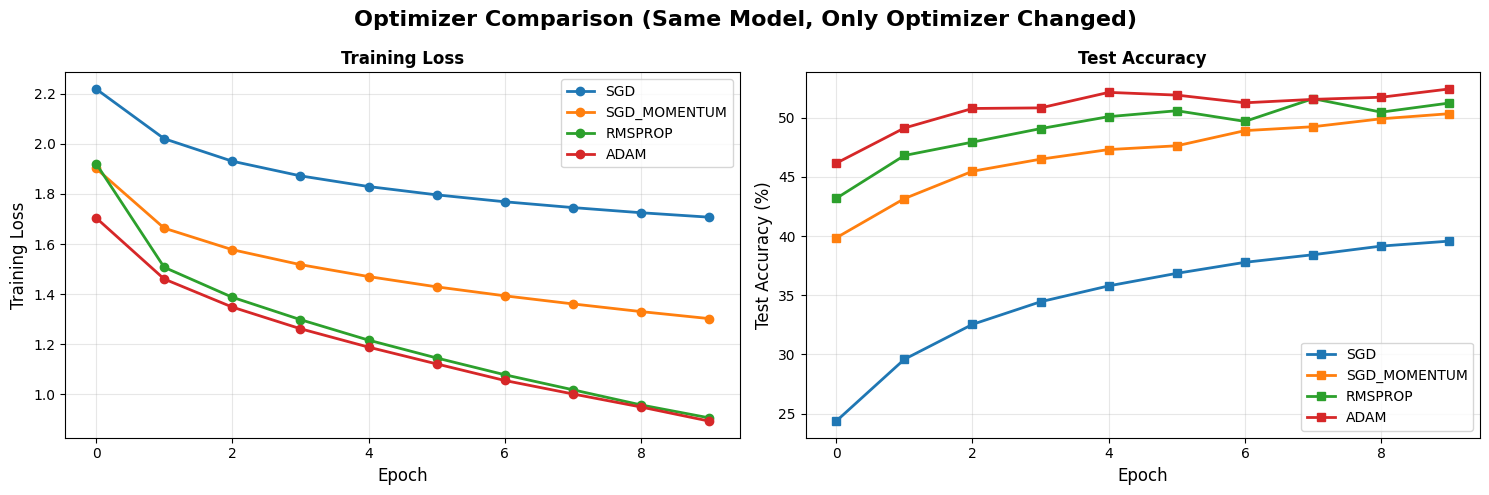


🎯 OPTIMIZER WINNER:
Best: ADAM with 52.42% accuracy


In [ ]:
# EXPERIMENT 2: OPTIMIZERS


print("\nNow let's use the SAME model (ReLU activation) and ONLY change optimizer")
print("Everything else stays identical!\n")

# Use the best activation from Experiment 1
OPTIMIZED_CONFIG = {
    **BASE_CONFIG,
    'activation': 'relu'  # Winner from Experiment 1
}

optimizers_to_test = [
    ('sgd', 0.001),
    ('sgd_momentum', 0.001),
    ('rmsprop', 0.001),
    ('adam', 0.001)
]

optimizer_results = {}

for opt_name, lr in optimizers_to_test:
    print(f"\n{'='*70}")
    print(f"Testing: {opt_name.upper()} optimizer (LR={lr})")
    print(f"{'='*70}")

    # Same model, different optimizer
    model = FlexibleMLP(**OPTIMIZED_CONFIG).to(device)

    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=10,
        lr=lr,
        optimizer_name=opt_name,
        verbose=True
    )

    optimizer_results[opt_name] = history

# Visualize optimizer comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Optimizer Comparison (Same Model, Only Optimizer Changed)',
             fontsize=16, fontweight='bold')

for opt_name, lr in optimizers_to_test:
    ax1.plot(optimizer_results[opt_name]['train_loss'],
             marker='o', label=opt_name.upper(), linewidth=2)
    ax2.plot(optimizer_results[opt_name]['test_acc'],
             marker='s', label=opt_name.upper(), linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Test Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


best_optimizer = max(optimizer_results.items(),
                     key=lambda x: x[1]['test_acc'][-1])
print(f"Best: {best_optimizer[0].upper()} with {best_optimizer[1]['test_acc'][-1]:.2f}% accuracy")

**Exercise3: Learning rate schedulers**

We found that the best optimizer is the ADAM for our case. But what about the learning rate?

We were experimenting with the fixed learning rate and assuming that it will be sufficient. But is this assumption holds true? Lets observe that in the below.


Using best activation (ReLU) + best optimizer (Adam)
Now we ONLY change the learning rate schedule


Testing: Fixed LR


Epoch 1/15: 100%|██████████| 391/391 [00:23<00:00, 16.60it/s, loss=1.6582, acc=39.00%]


Epoch 1/15 | Train Loss: 1.7396 | Train Acc: 39.00% | Test Loss: 1.5569 | Test Acc: 44.49%


Epoch 2/15: 100%|██████████| 391/391 [00:23<00:00, 16.53it/s, loss=1.5205, acc=46.44%]


Epoch 2/15 | Train Loss: 1.5141 | Train Acc: 46.44% | Test Loss: 1.4657 | Test Acc: 47.29%


...

Epoch 13/15 | Train Loss: 0.8126 | Train Acc: 71.62% | Test Loss: 1.3377 | Test Acc: 55.39%


Epoch 14/15: 100%|██████████| 391/391 [00:20<00:00, 18.79it/s, loss=0.7242, acc=72.45%]


Epoch 14/15 | Train Loss: 0.7891 | Train Acc: 72.45% | Test Loss: 1.3377 | Test Acc: 55.60%


Epoch 15/15: 100%|██████████| 391/391 [00:21<00:00, 18.57it/s, loss=0.8447, acc=72.94%]


Epoch 15/15 | Train Loss: 0.7739 | Train Acc: 72.94% | Test Loss: 1.3374 | Test Acc: 55.59%


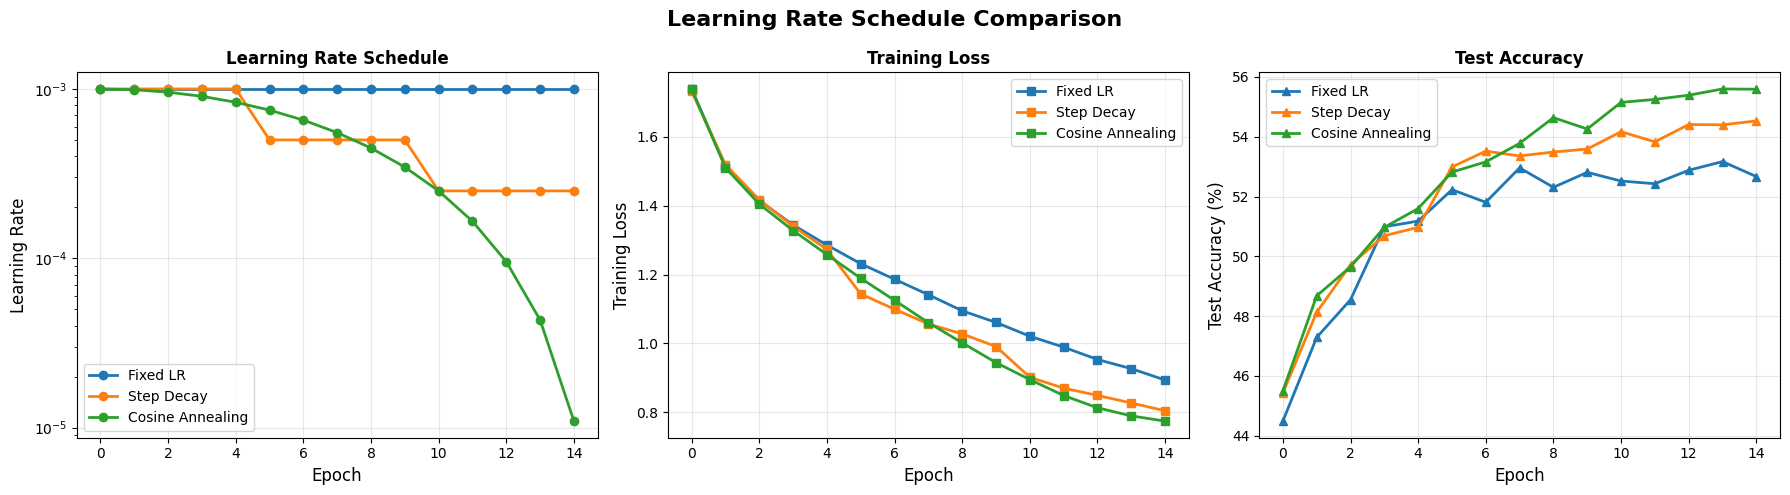

In [ ]:
# EXPERIMENT 3: LEARNING RATE SCHEDULES

print("\nUsing best activation (ReLU) + best optimizer (Adam)")
print("Now we ONLY change the learning rate schedule\n")

# Use the best activation from Experiment 1
OPTIMIZED_CONFIG = {
    **BASE_CONFIG,
    'activation': 'relu'  # Winner from Experiment 1
}
schedules_to_test = [
    (None, 'Fixed LR'),
    ('step', 'Step Decay'),
    ('cosine', 'Cosine Annealing')
]

schedule_results = {}

for scheduler, name in schedules_to_test:
    print(f"\n{'='*70}")
    print(f"Testing: {name}")
    print(f"{'='*70}")

    model = FlexibleMLP(**OPTIMIZED_CONFIG).to(device)

    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=15,
        lr=0.001,  # Higher initial LR for better visualization
        optimizer_name='adam',
        scheduler_type=scheduler,
        verbose=True
    )

    schedule_results[name] = history

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Rate Schedule Comparison', fontsize=16, fontweight='bold')

for name in [s[1] for s in schedules_to_test]:
    # LR schedule
    axes[0].plot(schedule_results[name]['learning_rates'],
                 marker='o', label=name, linewidth=2)
    # Train loss
    axes[1].plot(schedule_results[name]['train_loss'],
                 marker='s', label=name, linewidth=2)
    # Test accuracy
    axes[2].plot(schedule_results[name]['test_acc'],
                 marker='^', label=name, linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('Learning Rate Schedule', fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Training Loss', fontsize=12)
axes[1].set_title('Training Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[2].set_title('Test Accuracy', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_schedules.png', dpi=150, bbox_inches='tight')
plt.show()


**Exercise 4: Weight Initialization**

Okaay, so far we have decided the best activation (ReLu), best optimizer(Adam) and found a better choice for learning rate for better training(cosine decay). Lets go back to beginning and try out different weight initializations.


Using best: ReLU + Adam + Cosine Schedule
Now we ONLY change initialization method


Testing: Zeros


Epoch 1/8: 100%|██████████| 391/391 [00:12<00:00, 30.31it/s, loss=2.2950, acc=9.81%]


Epoch 1/8 | Train Loss: 2.3035 | Train Acc: 9.81% | Test Loss: 2.3034 | Test Acc: 10.00%


Epoch 2/8: 100%|██████████| 391/391 [00:12<00:00, 30.57it/s, loss=2.3066, acc=9.98%]


Epoch 2/8 | Train Loss: 2.3033 | Train Acc: 9.98% | Test Loss: 2.3030 | Test Acc: 10.00%


...

Epoch 6/8 | Train Loss: 1.2955 | Train Acc: 54.01% | Test Loss: 1.4426 | Test Acc: 50.40%


Epoch 7/8: 100%|██████████| 391/391 [00:12<00:00, 30.74it/s, loss=1.2280, acc=57.99%]


Epoch 7/8 | Train Loss: 1.1816 | Train Acc: 57.99% | Test Loss: 1.4103 | Test Acc: 52.04%


Epoch 8/8: 100%|██████████| 391/391 [00:12<00:00, 30.92it/s, loss=0.9621, acc=61.56%]


Epoch 8/8 | Train Loss: 1.0857 | Train Acc: 61.56% | Test Loss: 1.3993 | Test Acc: 52.25%


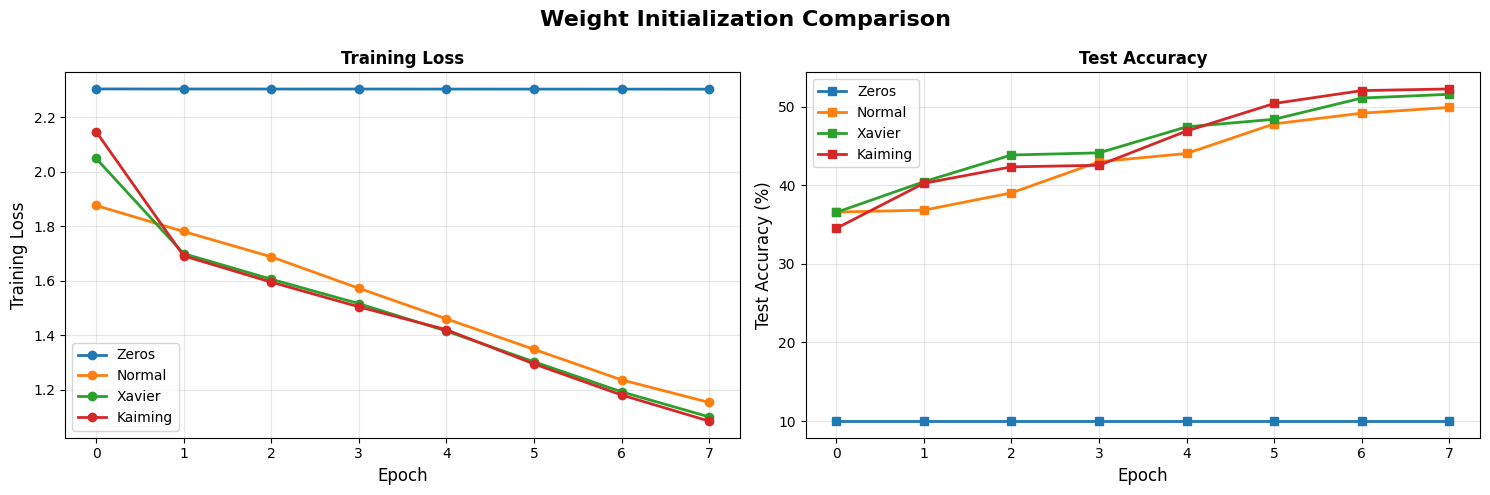

In [ ]:
# EXPERIMENT 4: WEIGHT INITIALIZATION

print("\nUsing best: ReLU + Adam + Cosine Schedule")
print("Now we ONLY change initialization method\n")

# Update config with best choices so far
BEST_CONFIG_SO_FAR = {
    **BASE_CONFIG,
    'activation': 'relu',

}
BEST_CONFIG_SO_FAR.pop('init_method', None)
inits_to_test = [
    ('zeros', 'Zeros'),
    ('normal', 'Normal'),
    ('xavier', 'Xavier'),
    ('kaiming', 'Kaiming')
]

init_results = {}

for init_method, name in inits_to_test:
    print(f"\n{'='*70}")
    print(f"Testing: {name}")
    print(f"{'='*70}")

    model = FlexibleMLP(
        **BEST_CONFIG_SO_FAR,
        init_method=init_method
    ).to(device)

    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=8,
        lr=0.01,
        optimizer_name='adam',
        scheduler_type='cosine',
        verbose=True
    )

    init_results[name] = history

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Weight Initialization Comparison', fontsize=16, fontweight='bold')

for init_method, name in inits_to_test:
    ax1.plot(init_results[name]['train_loss'],
             marker='o', label=name, linewidth=2)
    ax2.plot(init_results[name]['test_acc'],
             marker='s', label=name, linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Test Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weight_initialization.png', dpi=150, bbox_inches='tight')
plt.show()


**Exercise 5: Regularization**

Since we have a better intialization, I think we can start talking about the small but huge tricks. I am talking about the regularization, batch normalization.


EXPERIMENT 5: Regularization - Building the Ultimate Model

Starting with: ReLU + Adam + Cosine + Kaiming
Now we ADD regularization and see its effect 

Configuration: Baseline (No Regularization)
Dropout: 0.0, BatchNorm: False, Weight Decay: 0
Parameters: 820,874


Epoch 1/20: 100%|██████████| 391/391 [00:20<00:00, 19.19it/s, loss=1.6235, acc=40.89%]


Epoch 1/20 | Train Loss: 1.6896 | Train Acc: 40.89% | Test Loss: 1.5516 | Test Acc: 45.94%


Epoch 2/20: 100%|██████████| 391/391 [00:21<00:00, 18.51it/s, loss=1.3251, acc=49.04%]


Epoch 2/20 | Train Loss: 1.4549 | Train Acc: 49.04% | Test Loss: 1.4606 | Test Acc: 48.96%


...

Epoch 18/20 | Train Loss: 0.8200 | Train Acc: 70.85% | Test Loss: 1.2978 | Test Acc: 55.88%


Epoch 19/20: 100%|██████████| 391/391 [00:21<00:00, 18.58it/s, loss=0.8023, acc=71.20%]


Epoch 19/20 | Train Loss: 0.8062 | Train Acc: 71.20% | Test Loss: 1.2975 | Test Acc: 56.02%


Epoch 20/20: 100%|██████████| 391/391 [00:21<00:00, 18.34it/s, loss=0.7969, acc=71.60%]


Epoch 20/20 | Train Loss: 0.7978 | Train Acc: 71.60% | Test Loss: 1.2983 | Test Acc: 56.18%


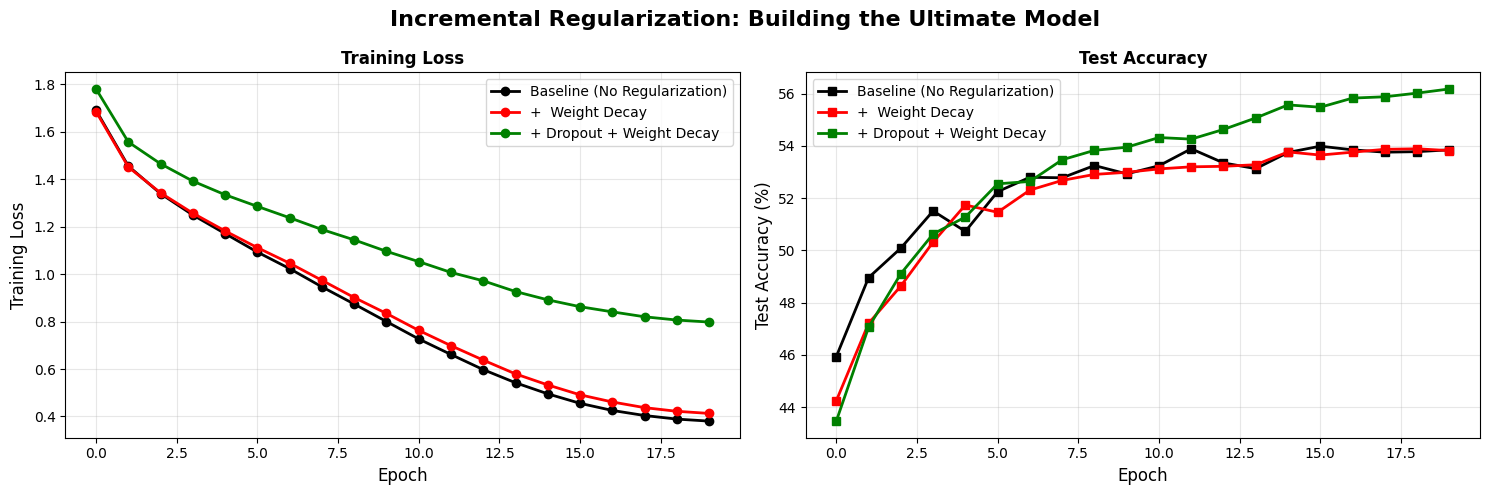

In [ ]:
# EXPERIMENT 5: REGULARIZATION

print("\n" + "="*70)
print("EXPERIMENT 5: Regularization - Building the Ultimate Model")
print("="*70)

# Baseline configuration
BASE_CONFIG = {
    'input_size': 3072,
    'hidden_sizes': [256, 128],
    'num_classes': 10,
    'use_batchnorm': False,
    'dropout_rate': 0.05,
    'init_method': 'kaiming'
}

print("\nStarting with: ReLU + Adam + Cosine + Kaiming")
print("Now we ADD regularization and see its effect ")

FINAL_BASE_CONFIG = {
    **BASE_CONFIG
}
# Remove keys we'll vary in the loop
FINAL_BASE_CONFIG.pop('dropout_rate', None)
FINAL_BASE_CONFIG.pop('use_batchnorm', None)

regularization_configs = [
    (0.0, False, 0, 'Baseline (No Regularization)'),
    (0, False, 1e-4, '+  Weight Decay'),
    (0.1, False, 1e-4, '+ Dropout + Weight Decay')

]

reg_results = {}

for dropout, batchnorm, weight_decay, name in regularization_configs:
    print(f"\n{'='*70}")
    print(f"Configuration: {name}")
    print(f"{'='*70}")

    model = FlexibleMLP(
        **FINAL_BASE_CONFIG,
        dropout_rate=dropout,
        use_batchnorm=batchnorm
    ).to(device)

    print(f"Dropout: {dropout}, BatchNorm: {batchnorm}, Weight Decay: {weight_decay}")
    print(f"Parameters: {model.count_parameters():,}")

    history = train_and_evaluate(
        model, trainloader, testloader,
        epochs=20,
        lr=0.001,
        optimizer_name='adam',
        scheduler_type='cosine',
        weight_decay=weight_decay,
        verbose=True
    )

    reg_results[name] = history

# Visualize incremental improvements
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Incremental Regularization: Building the Ultimate Model',
             fontsize=16, fontweight='bold')

colors = ['black', 'red', 'green']
linewidths = [2, 2, 2, 3]

for i, (dropout, batchnorm, weight_decay, name) in enumerate(regularization_configs):
    ax1.plot(reg_results[name]['train_loss'],
             marker='o', label=name, color=colors[i],
             linewidth=linewidths[i])
    ax2.plot(reg_results[name]['test_acc'],
             marker='s', label=name, color=colors[i],
             linewidth=linewidths[i])

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Test Accuracy', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('incremental_regularization.png', dpi=150, bbox_inches='tight')
plt.show()